In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/Job_1_resource_world_population.csv')

In [5]:
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [6]:
#perform initial data inspection
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [7]:
# Select numerical columns for calculations, excluding 'Rank' as it's an identifier
numerical_cols = df.select_dtypes(include=np.number).columns.drop('Rank', errors='ignore')

print("Mean:")
print(df[numerical_cols].mean())
print("\nMedian:")
print(df[numerical_cols].median())
print("\nVariance:")
print(df[numerical_cols].var())
print("\nStandard Deviation:")
print(df[numerical_cols].std())

Mean:
2022 Population                3.407441e+07
2020 Population                3.350107e+07
2015 Population                3.172996e+07
2010 Population                2.984524e+07
2000 Population                2.626947e+07
1990 Population                2.271022e+07
1980 Population                1.898462e+07
1970 Population                1.578691e+07
Area (km²)                     5.814494e+05
Density (per km²)              4.521270e+02
Growth Rate                    1.009577e+00
World Population Percentage    4.270513e-01
dtype: float64

Median:
2022 Population                5.559944e+06
2020 Population                5.493074e+06
2015 Population                5.307400e+06
2010 Population                4.942770e+06
2000 Population                4.292907e+06
1990 Population                3.825410e+06
1980 Population                3.141146e+06
1970 Population                2.604830e+06
Area (km²)                     8.119950e+04
Density (per km²)              9.534675e+01
Gr

In [8]:
# Define the start and end population columns
start_year_col = '1970 Population'
end_year_col = '2022 Population'

# Calculate the cumulative population growth percentage
# Handle potential division by zero for countries with 0 population in the start year
df['Cumulative Population Growth (%)'] = df.apply(
    lambda row: ((row[end_year_col] - row[start_year_col]) / row[start_year_col]) * 100
    if row[start_year_col] != 0 else np.nan,
    axis=1
)

# Display the relevant columns for verification
print(df[['Country/Territory', start_year_col, end_year_col, 'Cumulative Population Growth (%)']].head())

# Also display some statistics about the new column
print("\nStatistics for 'Cumulative Population Growth (%):'")
print(df['Cumulative Population Growth (%)'].describe())

  Country/Territory  1970 Population  2022 Population  \
0       Afghanistan         10752971         41128771   
1           Albania          2324731          2842321   
2           Algeria         13795915         44903225   
3    American Samoa            27075            44273   
4           Andorra            19860            79824   

   Cumulative Population Growth (%)  
0                        282.487510  
1                         22.264511  
2                        225.482036  
3                         63.519852  
4                        301.933535  

Statistics for 'Cumulative Population Growth (%):'
count     234.000000
mean      187.636814
std       281.069874
min       -62.700096
25%        35.587355
50%       132.331397
75%       260.940057
max      3067.271306
Name: Cumulative Population Growth (%), dtype: float64


In [9]:
df.columns

Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage',
       'Cumulative Population Growth (%)'],
      dtype='object')

In [10]:
df = df.rename(columns={'2020 Population': '2020'})
print(df.columns)

Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020', '2015 Population', '2010 Population',
       '2000 Population', '1990 Population', '1980 Population',
       '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate',
       'World Population Percentage', 'Cumulative Population Growth (%)'],
      dtype='object')


In [11]:
# Check available population columns
population_cols = [col for col in df.columns if 'Population' in col]
print(f"Available Population columns: {population_cols}")

# Based on the available data, '1900 Population' is not present.
# The earliest available population data is '1970 Population'.
# Please confirm if you would like to visualize '1970 Population' and '2022 Population'.

Available Population columns: ['2022 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population', 'World Population Percentage', 'Cumulative Population Growth (%)']


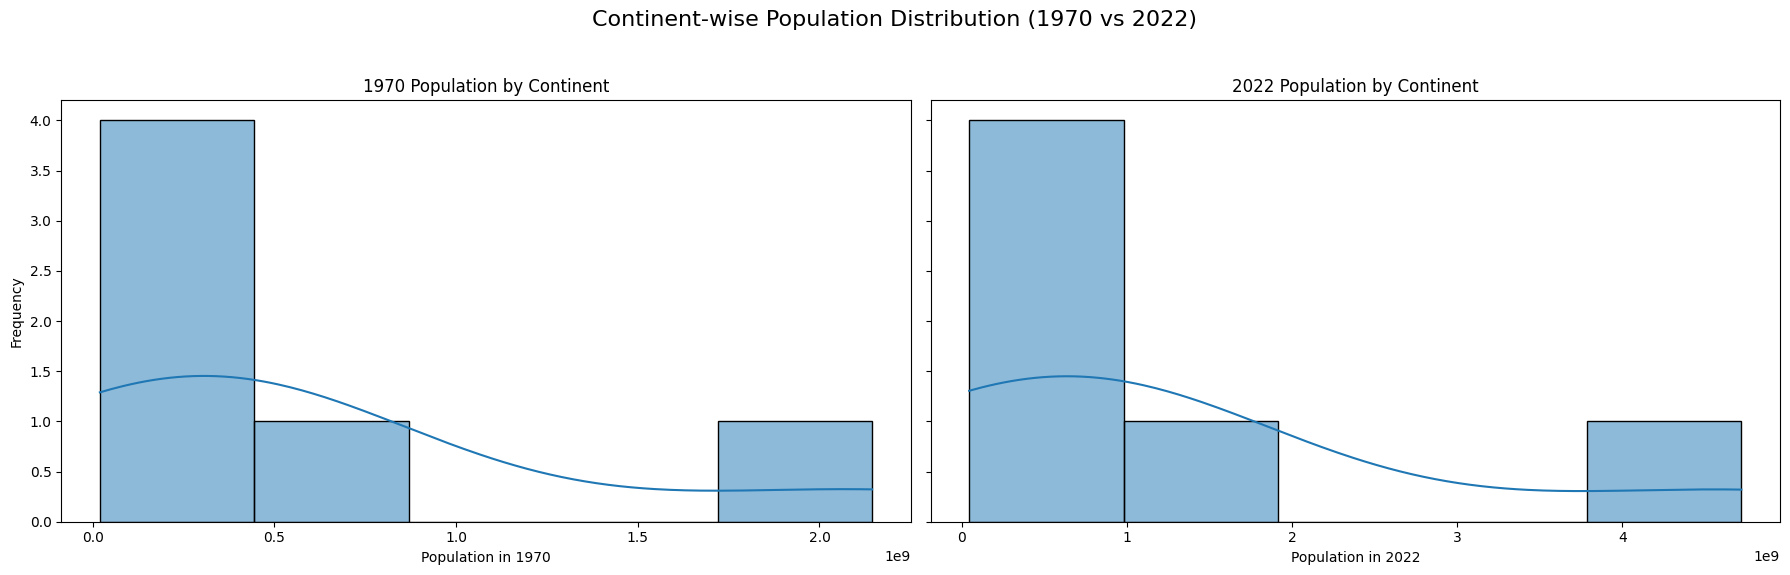

In [12]:
# Group by Continent and sum the population for 1970 and 2022
continent_population = df.groupby('Continent')[['1970 Population', '2022 Population']].sum().reset_index()

# Set up the matplotlib figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle('Continent-wise Population Distribution (1970 vs 2022)', fontsize=16)

# Histogram for 1970 Population
sns.histplot(data=continent_population, x='1970 Population', ax=axes[0], bins=5, kde=True)
axes[0].set_title('1970 Population by Continent')
axes[0].set_xlabel('Population in 1970')
axes[0].set_ylabel('Frequency')

# Histogram for 2022 Population
sns.histplot(data=continent_population, x='2022 Population', ax=axes[1], bins=5, kde=True)
axes[1].set_title('2022 Population by Continent')
axes[1].set_xlabel('Population in 2022')
axes[1].set_ylabel('Frequency') # Will be shared with the first plot due to sharey=True

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [13]:
numerical_cols_for_corr = df.select_dtypes(include=np.number).drop('Rank', axis=1, errors='ignore')
correlation_matrix = numerical_cols_for_corr.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                                  2022 Population      2020  2015 Population  \
2022 Population                          1.000000  0.999946         0.999490   
2020                                     0.999946  1.000000         0.999763   
2015 Population                          0.999490  0.999763         1.000000   
2010 Population                          0.998629  0.999105         0.999783   
2000 Population                          0.994605  0.995583         0.997340   
1990 Population                          0.987228  0.988724         0.991594   
1980 Population                          0.980285  0.982121         0.985724   
1970 Population                          0.973162  0.975254         0.979414   
Area (km²)                               0.453411  0.454993         0.458240   
Density (per km²)                       -0.027618 -0.027358        -0.026857   
Growth Rate                             -0.020863 -0.025116        -0.032154   
World Population Per

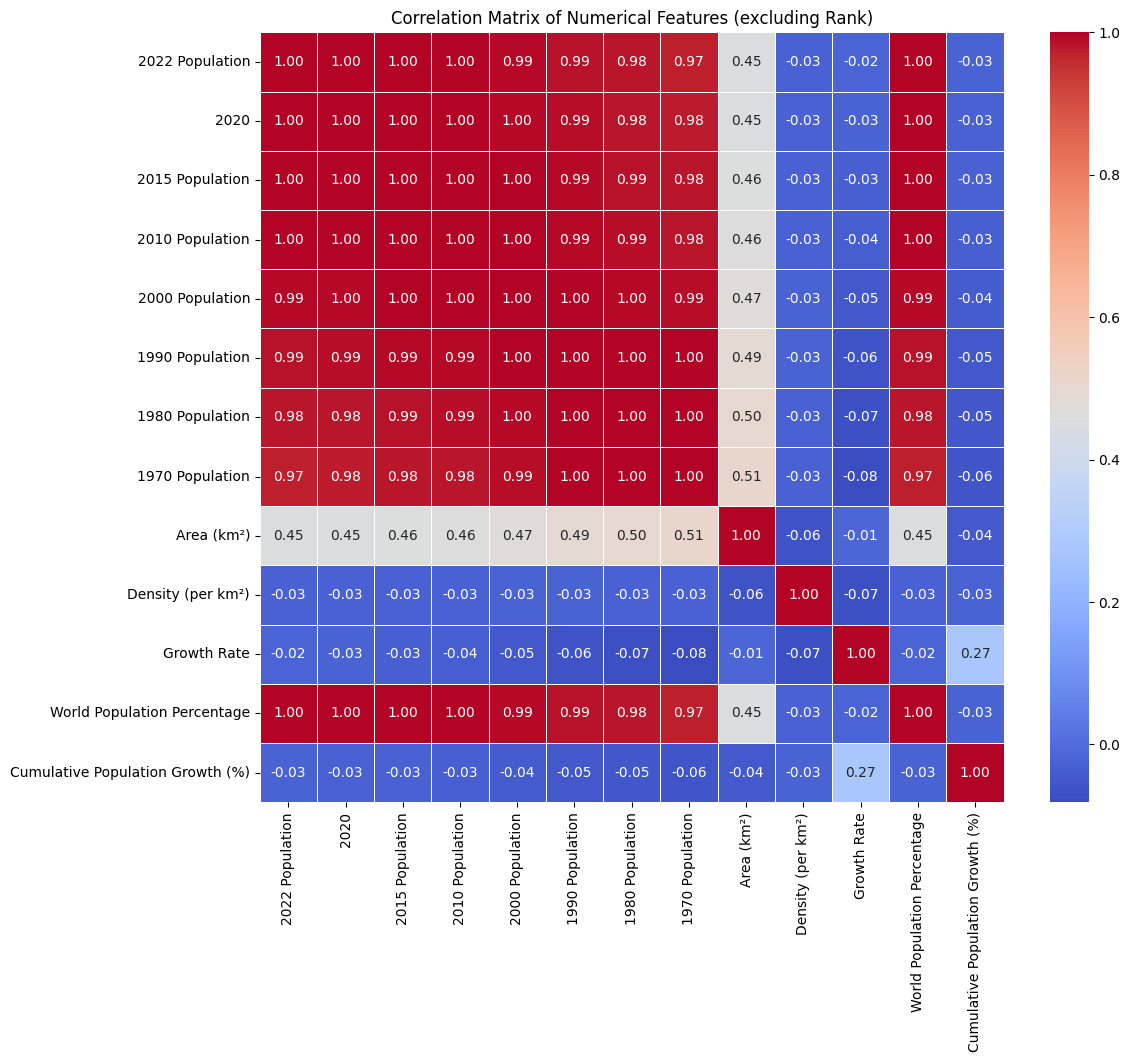

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (excluding Rank)')
plt.show()